In [ ]:
import json
import torch
import matplotlib.pyplot as plt

from bnbp5.bnn_intralayer import *
from bnbp5.trainnospikemne_intralayer_timeind_sliding_128 import Trainer
from bnbp5.mnist_spiketrain_sliding import *
import numpy as np
import matplotlib.pyplot as plt
from os.path import exists

from zanj import ZANJ

from torchvision import datasets, transforms
from torch import nn

torch.set_default_dtype(torch.float32)

In [ ]:
_HH_PARAMS: dict[str, float] = {
    "gna": 40.0,
    "gk": 35.0,
    "gl": 0.4, #0.3, 0.4

    "Ena": 55.0,
    "Ek": -77.0,
    "El": -60.0, #-65.0,

    "gm": 0.075,
    "ghca": 0.12, #12.0, #changed 0.12,
    "vthresh": -56.2, 
    "tau_max": 0.608,
    "Eca":  55.0, #120120.0,
    
    "gs": 0.04,
    "Vs": 0.0,
    "Iapp": 0.7,
    "lat_inhibition": False,
    "beta_n_modified": False,

    "Vt": -3.0,
    "Kp": 8.0,
    "a_d": 1.0,
    "a_r": 0.1,   
}   

# Adjust for DNN/BiLSTM/SNN
CFG1: BNNConfig = BNNConfig(lr = 0.0001, neuron_model = model_HH_RS, test_batch_sz = 25, train_batch_sz = 20, neuron_params = _HH_PARAMS, model_dims = [128,100,2], dt = 1000/220/45, plot_interm=True)
    
CFG2: DatasetConfig = DatasetConfig(
            sim_t = 2000,n_samples_train=300, n_samples_val = 50, n_samples_test=9000)
    

torch.manual_seed(15)
    
trainer = Trainer(CFG1, CFG2, False,subjects=["UM_7"], num_classes=2)    

1

In [ ]:
## Training

trainer.train()

trainer.measure_sliding_gradients(25, filename = "data/meas_slid_grad_UM7_wind_25") 
ZANJ().save(
        dict(
            CFG1 = CFG1,
            CFG2 = CFG2
        ),
        'data/configmeas_slid_grad_UM7_wind_25',
        )
print("DONE")
    

Model parameters:
Ws.0.weight
Ws.1.weight
Loading spiketrains for phase: train, n_samples = 300, offset = 0


In [11]:
sliding_grads = ZANJ().read("data/meas_slid_grad_MNIST_RS_10states_100wind_4000_v2.zanj") 

changes1 = sliding_grads.get('sliding_grad_1') #[190, 78400], [150, 1] #[22, 12800])
changes2 = sliding_grads.get('sliding_grad_2') #[190, 1000], [150, 10] #[22, 200]

z1 = sliding_grads.get('interm_out')[0][0].squeeze() #[19000, 100]
a1 = sliding_grads.get('interm_out')[0][1].squeeze() #[19000, 100]
z2 = sliding_grads.get('interm_out')[1][0].squeeze() #[19000, 10]
a2 = sliding_grads.get('interm_out')[1][1].squeeze() #[19000, 10]

#w1 = torch.tensor(sliding_grads['W1s']) #[100, 784] #[150,1] 
#w2 = torch.tensor(sliding_grads['W2s']) #[10, 100], #[150,10]

## PLOTS

In [ ]:
from matplotlib import font_manager as fm
from matplotlib import rc
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import matplotlib.patches as patches

font_path = "/home/mccruz/font_acumin"  # Replace with the path to your font file
prop = fm.FontProperties(fname=font_path, size = 14)
prop2 = fm.FontProperties(fname=font_path, size = 16)

In [ ]:
def fig_4(sliding_grads, start = 0, end = 40, inc = 1000, window_size = 25, dt = 0.1):
    def set_ticks(windowed_axis = True, inc = inc, N = end, dt = dt):
        
       # print(" ..", windowed_size)
        scale = window_size if windowed_axis else 1
        inc = inc // scale
        if windowed_axis == True:
            print("pr", "inc", inc, N,dt, scale, [f'{i*dt*scale:.0f}' for i in range(0,N+1,inc)])
        plt.xticks(range(0,N+1,inc), [f'{i*dt*scale:.0f}' for i in range(0,N+1,inc)], fontproperties=prop)
 
    T2 = sliding_grads.get('T2_out').cpu().detach().numpy()
    fig = plt.figure(figsize = (10, 12))          
    plt.subplot(3, 2, 1)
    plt.plot(T2)
    plt.title('A. All Output Layer Traces', fontsize=34, fontproperties=prop2)
    plt.ylabel('Neuron index', fontsize = 13, fontproperties=prop)
    set_ticks(False, N = int(end/dt))
    hi_color = 'black'
    hi_width = 1.5
    #plt.axvspan(11000, 15000, edgecolor=hi_color, linestyle='--', linewidth=hi_width, facecolor='none')
    #plt.axvspan(400, 900, 0, edgecolor=hi_color, linestyle='--', linewidth=hi_width, facecolor='none')
    plt.xlim(start*100, int(end/dt))
    plt.yticks( fontproperties=prop) 
    plt.legend(np.arange(0,10,1), fontsize = 8, prop=prop, loc='lower left')

    plt.subplot(3, 2, 2)
    plt.imshow(T2.transpose(), aspect='auto', cmap='gist_rainbow', vmin = 0.0, vmax = 1.0)
    #plt.colorbar()#fontproperties=prop)
    colorbar = plt.colorbar()
    
    for label in colorbar.ax.get_yticklabels():
        label.set_fontproperties(prop)  # Apply the custom font to each tick label

    
    plt.ylabel('Neuron output', fontsize = 13, fontproperties=prop)
    plt.title('B. Output Layer Raster Plot', fontsize=34, fontproperties=prop2)
    set_ticks(False, N = int(end/dt))
    #plt.axvspan(2100, 2400, 0, 10, edgecolor=hi_color, linestyle='--', linewidth=hi_width, facecolor='none')
    #plt.axvspan(400, 900, 0, 10, edgecolor=hi_color, linestyle='--', linewidth=hi_width, facecolor='none')
    plt.xlim(start*100, int(end/dt))
    plt.yticks( fontproperties=prop) 

    for l, label, numbers in zip([1,2], ['Hidden', 'Output'], [['E.', 'F.'], ['C.', 'D.']]):
        plot_idx = 5 if l == 1 else 3 
        plt.subplot(3, 2, plot_idx+1)
        if l == 1:
            changes = sliding_grads.get('sliding_grad_1')
            #print(len(changes))
        else:
            changes = sliding_grads.get('sliding_grad_2')
            #print(len(changes))
        vmin=-0.1; vmax=0.1
        plt.imshow(changes.detach().cpu().numpy().transpose(), aspect='auto', cmap='gnuplot', vmin=vmin, vmax=vmax)
        cbar = plt.colorbar(ticks=[vmin, 0.0, vmax])
       
        cbar.ax.set_yticklabels(['< -0.1', '0', '> 0.1'])
        
        set_ticks()
        #set_ticks(False, N = int(end/dt))
    
        plt.ylabel('Weight (flattened)', fontsize = 13, fontproperties=prop)
        plt.title(f'{numbers[1]} {label} Gradients Raster Plot', fontproperties=prop2)
        #plt.axvspan(210, 240, 0, changes.shape[1], edgecolor=hi_color, linestyle='--', linewidth=hi_width, facecolor='none')
        #plt.axvspan(40, 90, 0, changes.shape[1], edgecolor=hi_color, linestyle='--', linewidth=hi_width, facecolor='none')
        #plt.axvspan(110, 150, 0, changes.shape[1], edgecolor=hi_color, linestyle='--', linewidth=hi_width, facecolor='none')
        plt.xlim(start//dt//window_size, end//dt//window_size)
        plt.yticks( fontproperties=prop) 
        
        
        plt.subplot(3, 2, plot_idx)
        if l == 1:
            changes = changes[:, ::10] # Too many values to plot.
        print("CHANGES", changes.shape)
        plt.plot(changes.cpu().numpy())
        set_ticks()
        plt.title(f'{numbers[0]} {label} Instantaneous Gradients', fontproperties=prop2)
        plt.ylabel('Gradient', fontsize = 14, fontproperties=prop)
       # plt.axvspan(210, 240, edgecolor=hi_color, linestyle='--', linewidth=hi_width, facecolor='none')
       # plt.axvspan(110, 150, edgecolor=hi_color, linestyle='--', linewidth=hi_width, facecolor='none')
        plt.xlim(start//dt//window_size, end//dt//window_size)
        plt.yticks( fontproperties=prop) 

        for label in cbar.ax.get_yticklabels():
            label.set_fontproperties(prop)  # Apply the custom font to each tick label
        

    fig.text(0.25, -0.01, 'Time (ms)', ha='center', fontsize=13, fontproperties=prop)
    fig.text(0.75, -0.01, 'Time (ms)', ha='center', fontsize=13, fontproperties=prop)
    plt.tight_layout()
    
    plt.show()
    
    for i in range(20):
        plt.plot(changes[:,i].cpu().numpy())
        set_ticks()
        plt.title(f'{numbers[0]} {label} Instantaneous Gradients', fontproperties=prop2)
        plt.ylabel('Gradient', fontsize = 14, fontproperties=prop)
       # plt.axvspan(210, 240, edgecolor=hi_color, linestyle='--', linewidth=hi_width, facecolor='none')
       # plt.axvspan(110, 150, edgecolor=hi_color, linestyle='--', linewidth=hi_width, facecolor='none')
        plt.xlim(start//dt//window_size, end//dt//window_size)
        plt.yticks( fontproperties=prop) 
        plt.show()

pr inc 40 401 0.1 25 ['0', '100', '200', '300', '400', '500', '600', '700', '800', '900', '1000']
CHANGES torch.Size([160, 7840])
pr inc 40 401 0.1 25 ['0', '100', '200', '300', '400', '500', '600', '700', '800', '900', '1000']
pr inc 40 401 0.1 25 ['0', '100', '200', '300', '400', '500', '600', '700', '800', '900', '1000']
CHANGES torch.Size([160, 1000])
pr inc 40 401 0.1 25 ['0', '100', '200', '300', '400', '500', '600', '700', '800', '900', '1000']


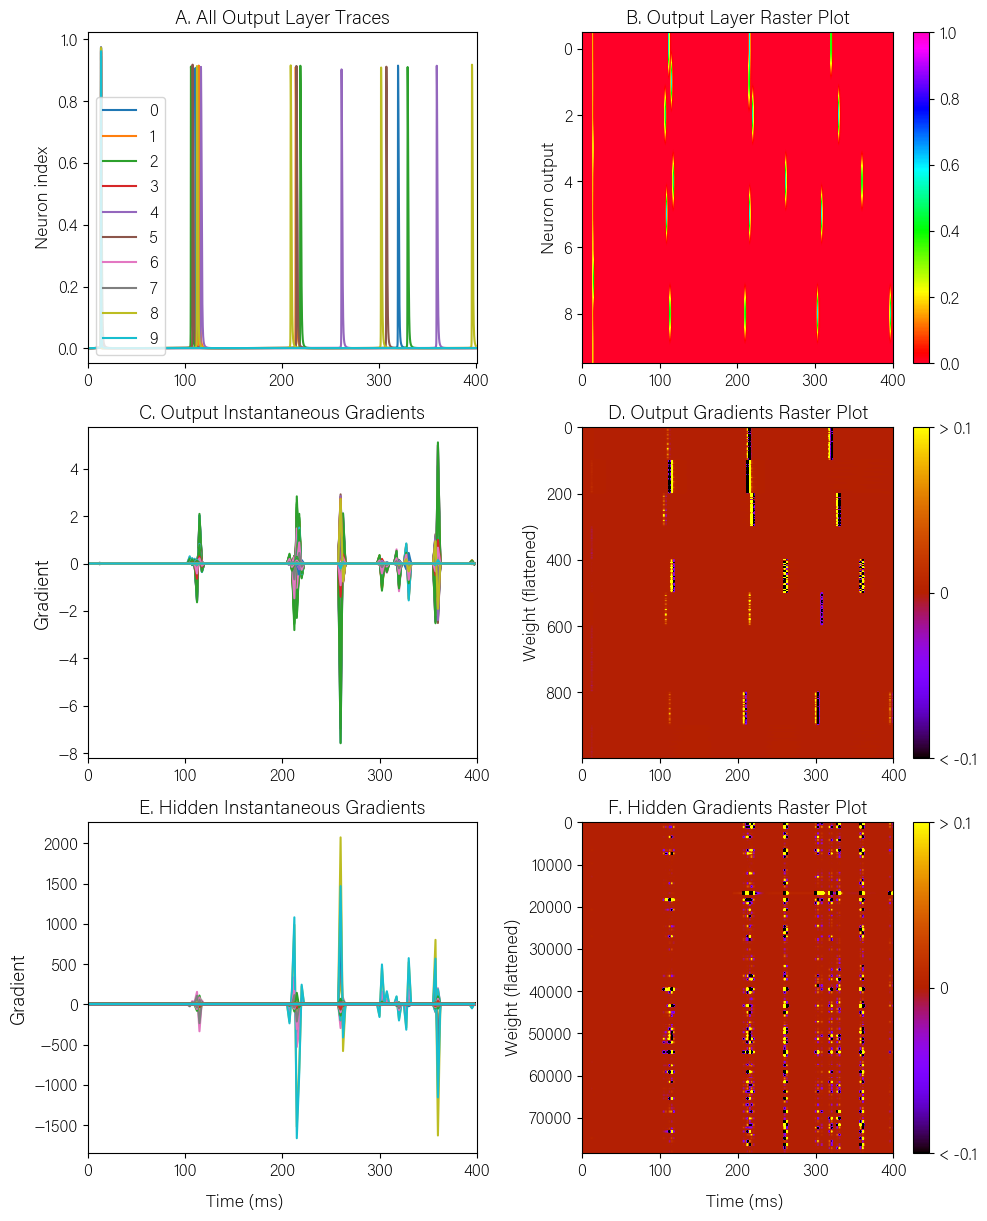

pr inc 40 401 0.1 25 ['0', '100', '200', '300', '400', '500', '600', '700', '800', '900', '1000']


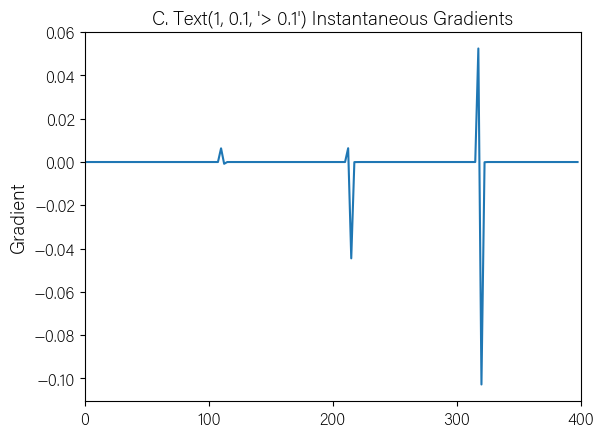

pr inc 40 401 0.1 25 ['0', '100', '200', '300', '400', '500', '600', '700', '800', '900', '1000']


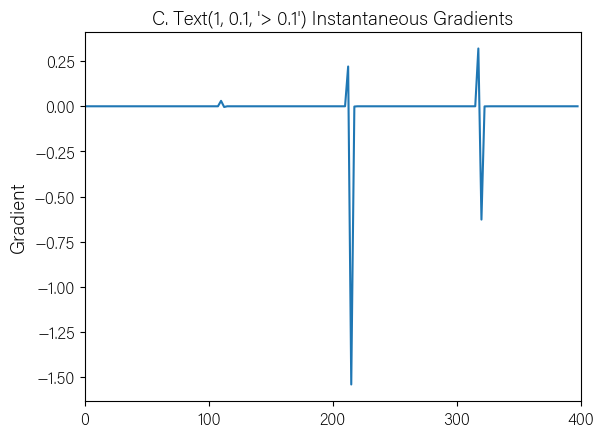

pr inc 40 401 0.1 25 ['0', '100', '200', '300', '400', '500', '600', '700', '800', '900', '1000']


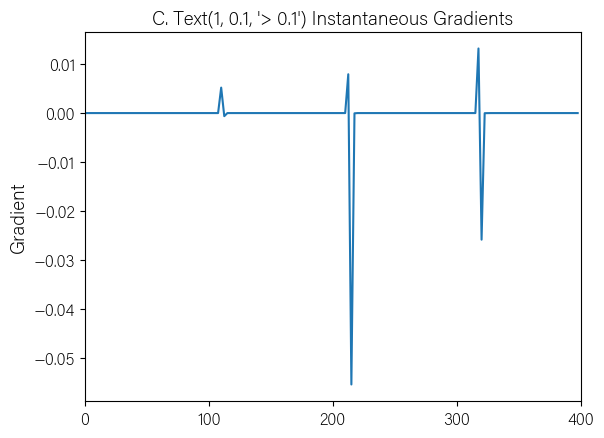

pr inc 40 401 0.1 25 ['0', '100', '200', '300', '400', '500', '600', '700', '800', '900', '1000']


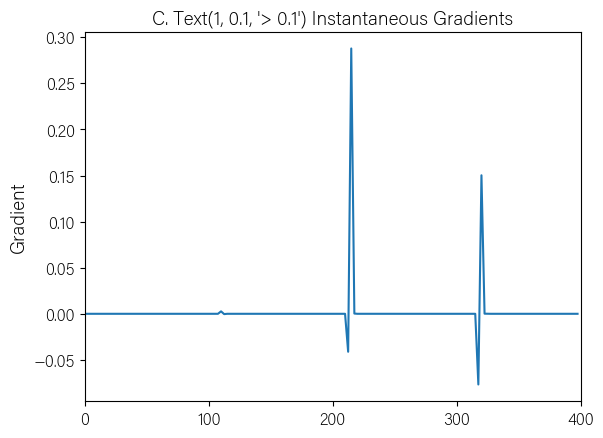

pr inc 40 401 0.1 25 ['0', '100', '200', '300', '400', '500', '600', '700', '800', '900', '1000']


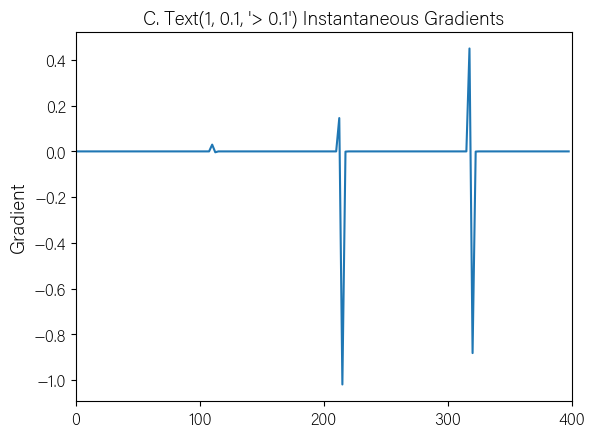

pr inc 40 401 0.1 25 ['0', '100', '200', '300', '400', '500', '600', '700', '800', '900', '1000']


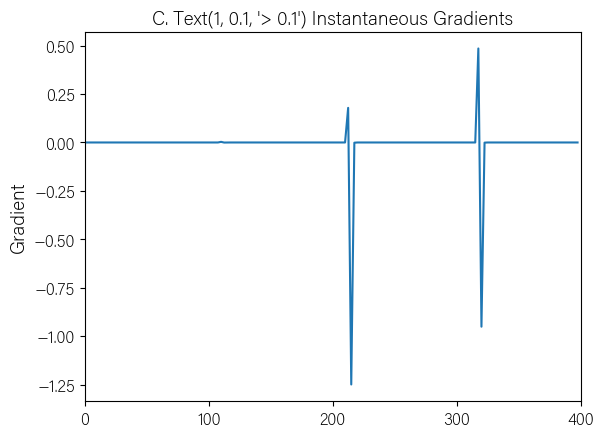

pr inc 40 401 0.1 25 ['0', '100', '200', '300', '400', '500', '600', '700', '800', '900', '1000']


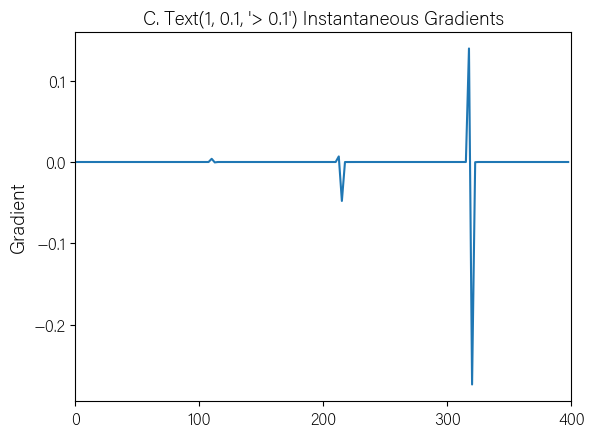

pr inc 40 401 0.1 25 ['0', '100', '200', '300', '400', '500', '600', '700', '800', '900', '1000']


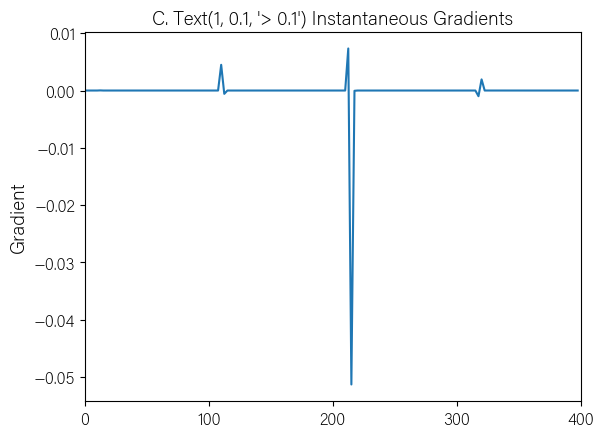

pr inc 40 401 0.1 25 ['0', '100', '200', '300', '400', '500', '600', '700', '800', '900', '1000']


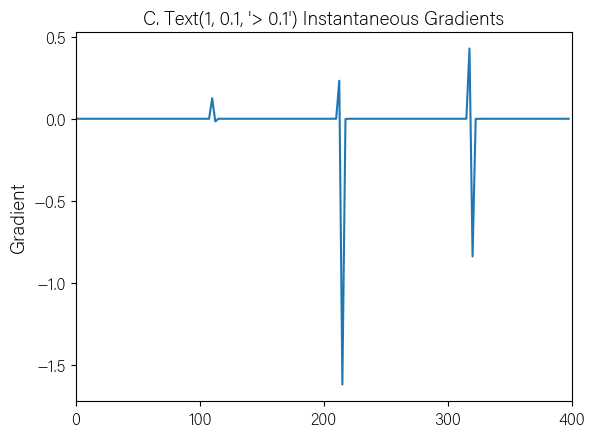

pr inc 40 401 0.1 25 ['0', '100', '200', '300', '400', '500', '600', '700', '800', '900', '1000']


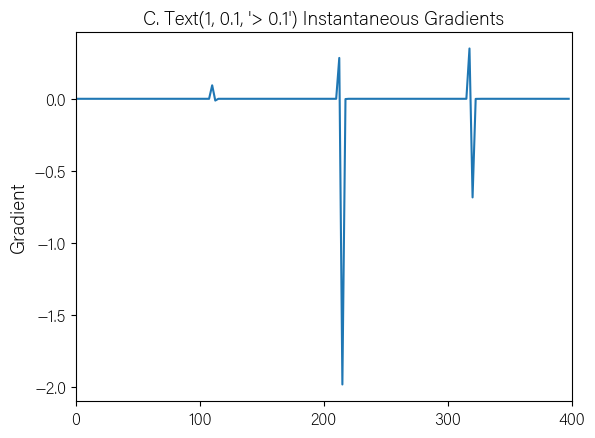

pr inc 40 401 0.1 25 ['0', '100', '200', '300', '400', '500', '600', '700', '800', '900', '1000']


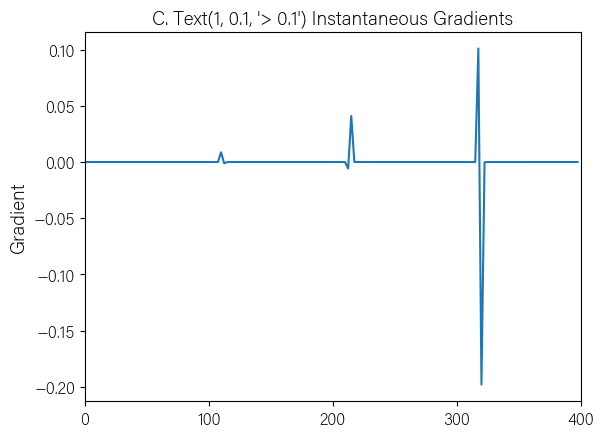

pr inc 40 401 0.1 25 ['0', '100', '200', '300', '400', '500', '600', '700', '800', '900', '1000']


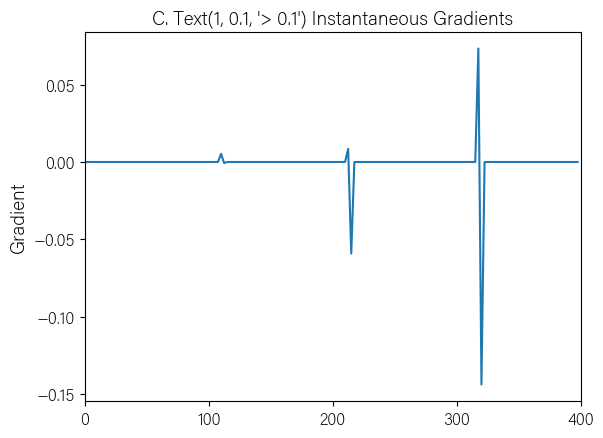

pr inc 40 401 0.1 25 ['0', '100', '200', '300', '400', '500', '600', '700', '800', '900', '1000']


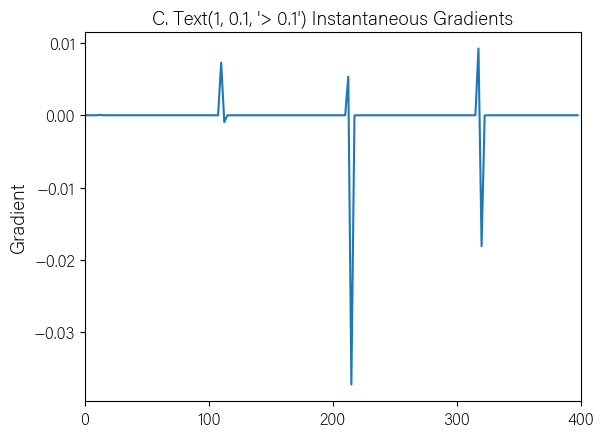

pr inc 40 401 0.1 25 ['0', '100', '200', '300', '400', '500', '600', '700', '800', '900', '1000']


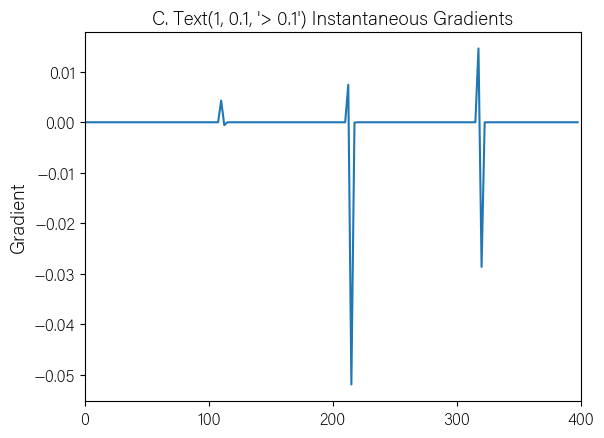

pr inc 40 401 0.1 25 ['0', '100', '200', '300', '400', '500', '600', '700', '800', '900', '1000']


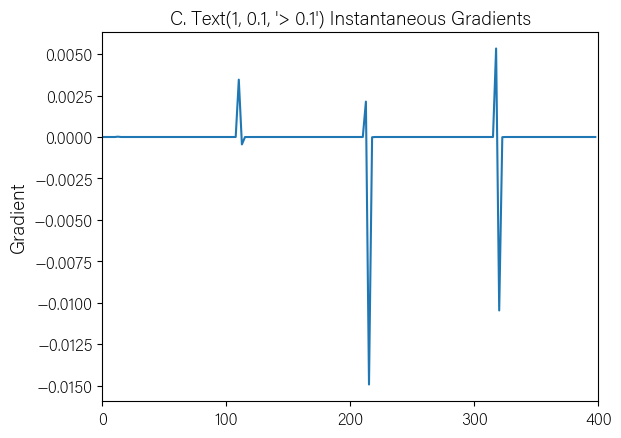

pr inc 40 401 0.1 25 ['0', '100', '200', '300', '400', '500', '600', '700', '800', '900', '1000']


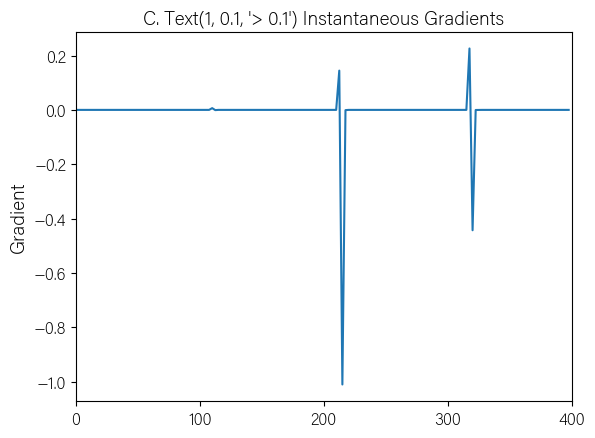

pr inc 40 401 0.1 25 ['0', '100', '200', '300', '400', '500', '600', '700', '800', '900', '1000']


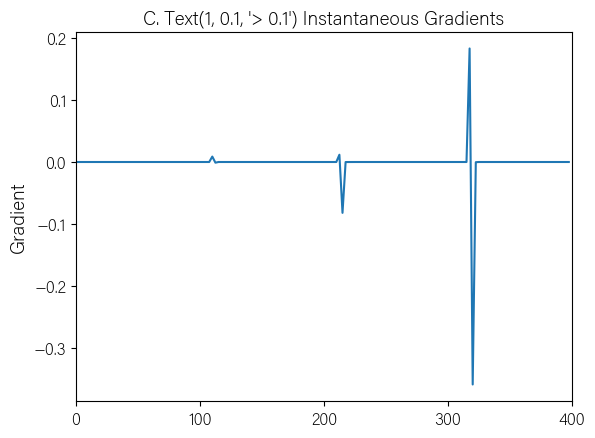

pr inc 40 401 0.1 25 ['0', '100', '200', '300', '400', '500', '600', '700', '800', '900', '1000']


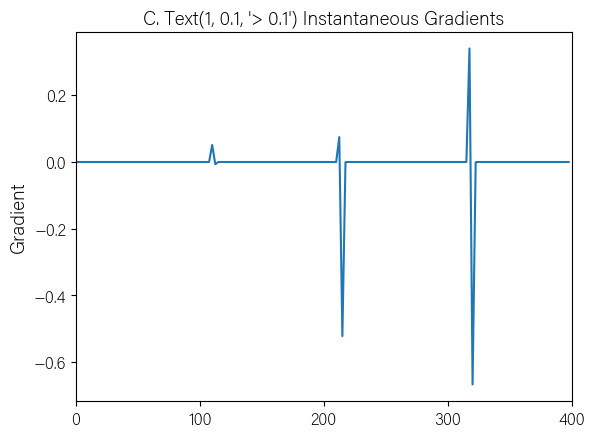

pr inc 40 401 0.1 25 ['0', '100', '200', '300', '400', '500', '600', '700', '800', '900', '1000']


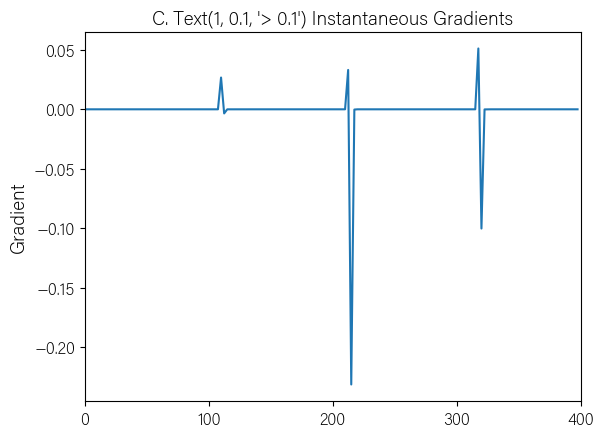

pr inc 40 401 0.1 25 ['0', '100', '200', '300', '400', '500', '600', '700', '800', '900', '1000']


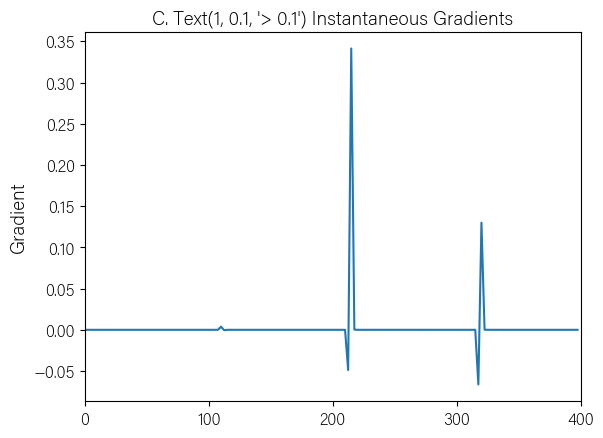

In [11]:
fig_4(sliding_grads, start = 0, end = 401, inc = 1000)

In [ ]:
def fig_4v2(sliding_grads, start = 0, end = 40, inc = 1000, window_size = 25, dt = 0.1):
    colors = ["red", "orange",  "green", "blue", "#F26858", "#1B9AAA" , "#A4B547",  "#201E50", "#d62728","#2CA02C" ]#plt.cm.tab10(np.linspace(0, 1, num_chunks))  # 10 distinct colors

    
    def set_ticks(windowed_axis = True, inc = inc, N = end, dt = dt):
        
       # print(" ..", windowed_size)
        scale = window_size if windowed_axis else 1
        inc = inc // scale
        if windowed_axis == True:
            print("pr", "inc", inc, N,dt, scale, [f'{i*dt*scale:.0f}' for i in range(0,N+1,inc)])
        plt.xticks(range(0,N+1,inc), [f'{i*dt*scale:.0f}' for i in range(0,N+1,inc)], fontproperties=prop)
 
    T2 = sliding_grads.get('T2_out').cpu().detach().numpy()
    fig = plt.figure(figsize = (10, 12))          
    plt.subplot(3, 2, 1)
    colors = ["red", "orange",  "green", "blue", "#F26858", "#1B9AAA" , "#A4B547",  "#201E50", "#d62728","#2CA02C" ]#plt.cm.tab10(np.linspace(0, 1, num_chunks))  # 10 distinct colors

    print(T2.shape)
    for i in range(10):
        plt.plot(T2[:,i], color=colors[i], linewidth=1.5, label=f'{i}')  # use individual color
    plt.title('A. All Output Layer Traces', fontsize=34, fontproperties=prop2)
    plt.ylabel('Neuron index', fontsize = 13, fontproperties=prop)
    set_ticks(False, N = int(end/dt))
    hi_color = 'black'
    hi_width = 1.5
    #plt.axvspan(11000, 15000, edgecolor=hi_color, linestyle='--', linewidth=hi_width, facecolor='none')
    #plt.axvspan(400, 900, 0, edgecolor=hi_color, linestyle='--', linewidth=hi_width, facecolor='none')
    plt.xlim(start*100, int(end/dt))
    plt.yticks( fontproperties=prop) 
    plt.legend(np.arange(0,10,1), fontsize = 8, prop=prop, loc='lower left')

    plt.subplot(3, 2, 2)
    plt.imshow(T2.transpose(), aspect='auto', cmap='gist_rainbow', vmin = 0.0, vmax = 1.0)
    #plt.colorbar()#fontproperties=prop)
    colorbar = plt.colorbar()
    
    for label in colorbar.ax.get_yticklabels():
        label.set_fontproperties(prop)  # Apply the custom font to each tick label

    
    plt.ylabel('Neuron output', fontsize = 13, fontproperties=prop)
    plt.title('B. Output Layer Raster Plot', fontsize=34, fontproperties=prop2)
    set_ticks(False, N = int(end/dt))
    plt.xlim(start*100, int(end/dt))
    plt.yticks( fontproperties=prop) 

    for l, label, numbers in zip([1,2], ['Hidden', 'Output'], [['E.', 'F.'], ['C.', 'D.']]):
       # --- 3–6. Gradient plots ---
    for l, label, numbers in zip([1, 2], ['Hidden', 'Output'], [['D.', 'F.'], ['D.', 'F.']]):
        changes_key = 'sliding_grad_1' if l == 1 else 'sliding_grad_2'
        changes = sliding_grads.get(changes_key)

        # Gradients raster plot (row 1 for hidden, row 2 for output)
        ax_raster = fig.add_subplot(gs[l, 1])
        vmin, vmax = -0.1, 0.1
        im_raster = ax_raster.imshow(changes.cpu().numpy().T, aspect='auto', cmap='gnuplot', vmin=vmin, vmax=vmax)
        cbar = fig.colorbar(im_raster, ax=ax_raster, ticks=[vmin, 0.0, vmax])
        cbar.ax.set_yticklabels(['< -0.1', '0', '> 0.1'])
        for label_tick in cbar.ax.get_yticklabels():
            label_tick.set_fontproperties(prop)
        set_ticks(ax_raster)
        ax_raster.set_ylabel('Gradient (flattened)', fontsize=13, fontproperties=prop)
        ax_raster.set_title(f'{numbers[1]} {label} Gradients Raster Plot', fontproperties=prop2)
        ax_raster.set_xlim(start // dt // window_size, end // dt // window_size)

        ax_line = fig.add_subplot(gs[l, 0])

        if l == 1:
            changes = changes[:, ::10]  # too many values otherwise
        print("CHANGES", changes.shape)

        changes_np = changes.cpu().numpy()
        num_chunks = changes_np.shape[1] // 10

        for i in range(10):
            chunk = changes_np[:, i * num_chunks:(i + 1) * num_chunks]
            if l == 2:
                ax_line.plot(chunk - i * 1 * (l - 1) - i * 200 * (2 - l), color=colors[i], linewidth=0.1)
                ax_line.set_ylim(-10, 1)
                ax_line.set_yticks([])
            if l == 1:
                ax_line.plot(chunk - i * 1 * (l - 1) - i * 200 * (2 - l), color=colors[i], linewidth=0.05)
                ax_line.set_ylim(-1900, 200)
                ax_line.set_yticks([])

        set_ticks(ax_line)
        ax_line.set_title(f'{numbers[0]} {label} Correct Neuron Instantaneous Gradients', fontproperties=prop2)
        ax_line.set_ylabel('Gradient (flattened)', fontsize=14, fontproperties=prop)
        ax_line.set_xlim(start // dt // window_size, end // dt // window_size)

    # Shared x labels
    fig.text(0.25, -0.01, 'Time (ms)', ha='center', fontsize=13, fontproperties=prop)
    fig.text(0.75, -0.01, 'Time (ms)', ha='center', fontsize=13, fontproperties=prop)

    plt.tight_layout()
    plt.show()

(4000, 10)
pr inc 40 401 0.1 25 ['0', '100', '200', '300', '400', '500', '600', '700', '800', '900', '1000']
CHANGES torch.Size([160, 7840])
pr inc 40 401 0.1 25 ['0', '100', '200', '300', '400', '500', '600', '700', '800', '900', '1000']
pr inc 40 401 0.1 25 ['0', '100', '200', '300', '400', '500', '600', '700', '800', '900', '1000']
CHANGES torch.Size([160, 1000])
pr inc 40 401 0.1 25 ['0', '100', '200', '300', '400', '500', '600', '700', '800', '900', '1000']


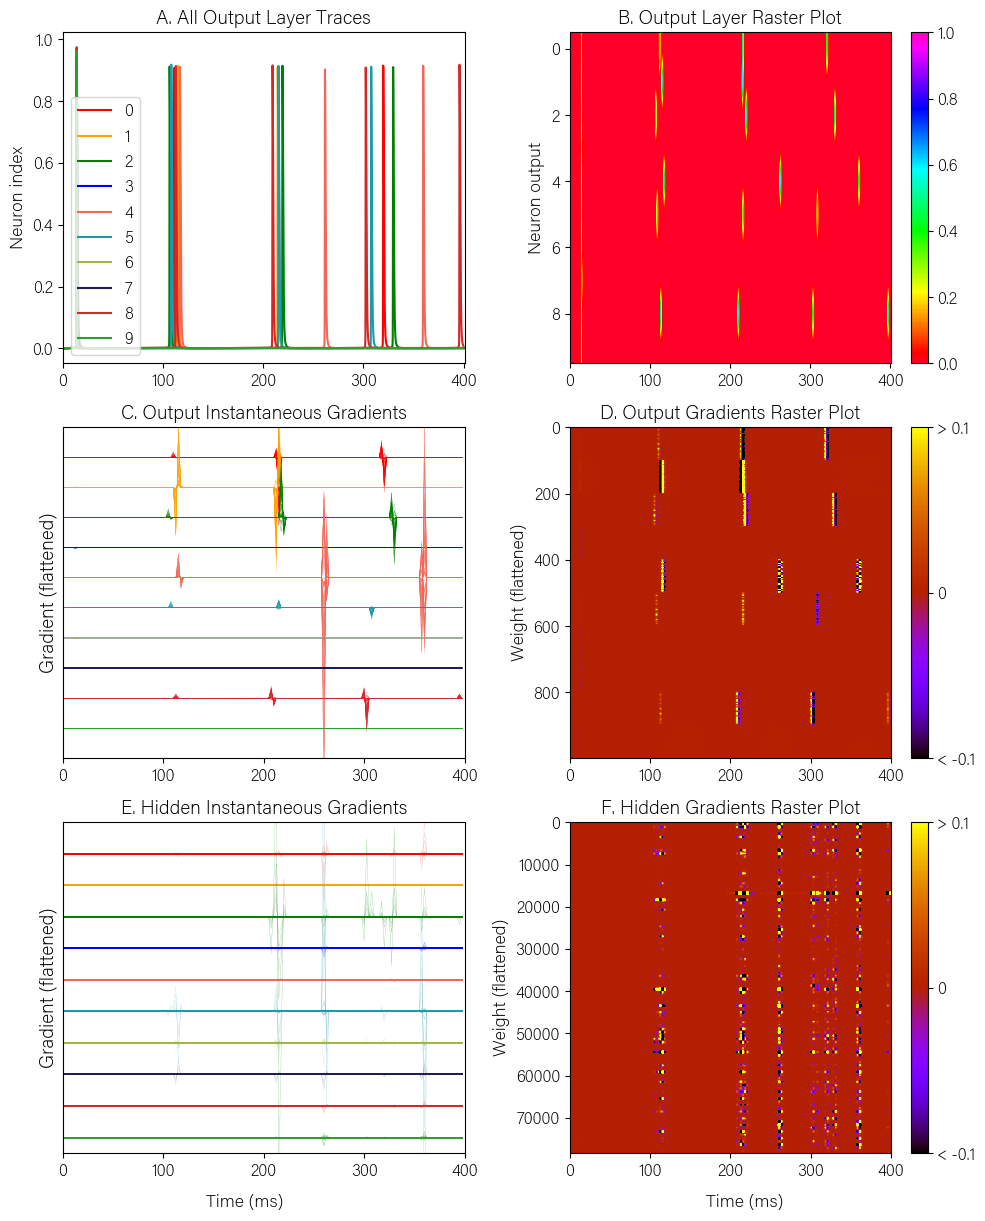

pr inc 40 401 0.1 25 ['0', '100', '200', '300', '400', '500', '600', '700', '800', '900', '1000']


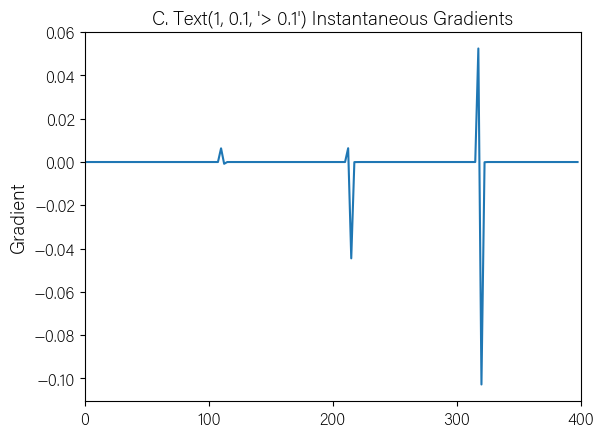

pr inc 40 401 0.1 25 ['0', '100', '200', '300', '400', '500', '600', '700', '800', '900', '1000']


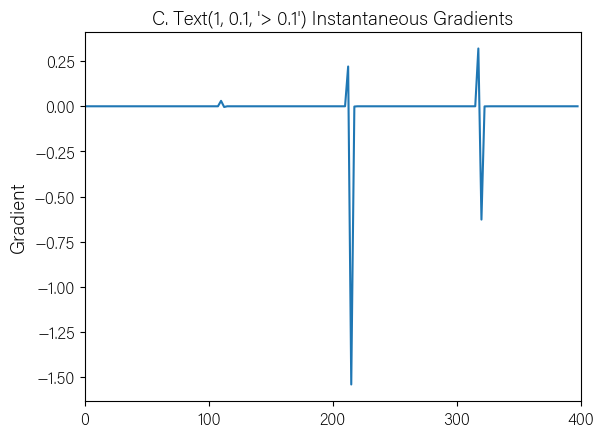

pr inc 40 401 0.1 25 ['0', '100', '200', '300', '400', '500', '600', '700', '800', '900', '1000']


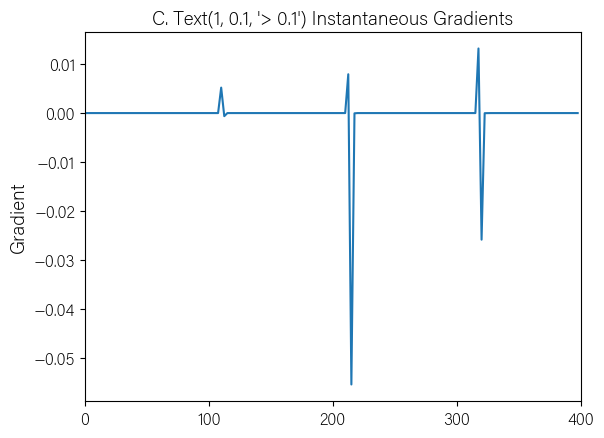

pr inc 40 401 0.1 25 ['0', '100', '200', '300', '400', '500', '600', '700', '800', '900', '1000']


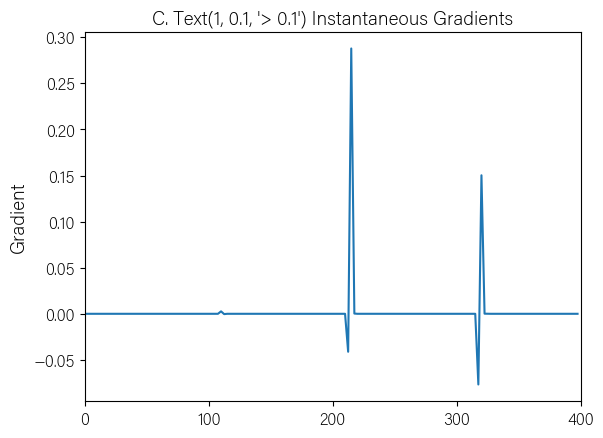

pr inc 40 401 0.1 25 ['0', '100', '200', '300', '400', '500', '600', '700', '800', '900', '1000']


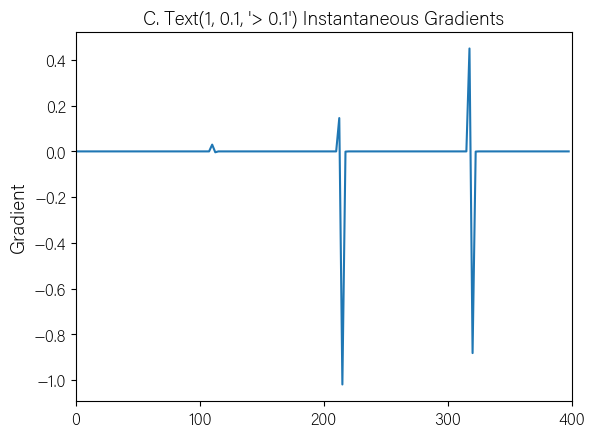

pr inc 40 401 0.1 25 ['0', '100', '200', '300', '400', '500', '600', '700', '800', '900', '1000']


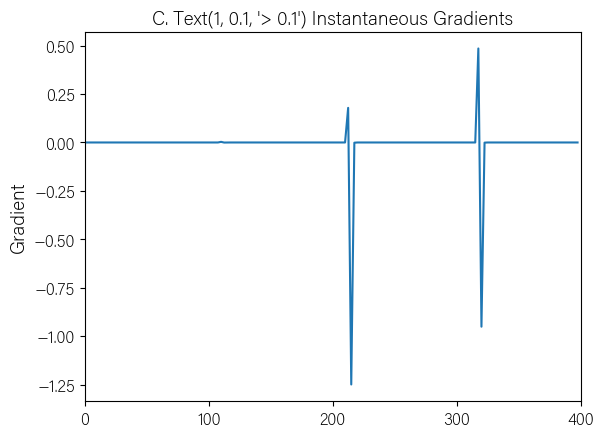

pr inc 40 401 0.1 25 ['0', '100', '200', '300', '400', '500', '600', '700', '800', '900', '1000']


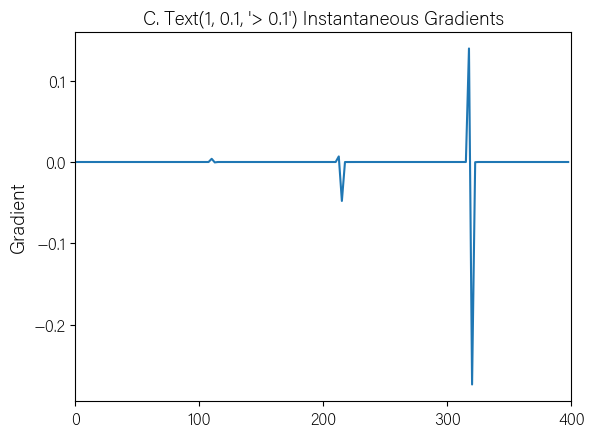

pr inc 40 401 0.1 25 ['0', '100', '200', '300', '400', '500', '600', '700', '800', '900', '1000']


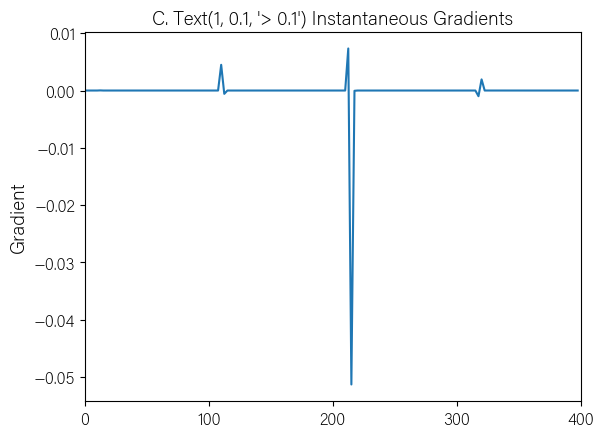

pr inc 40 401 0.1 25 ['0', '100', '200', '300', '400', '500', '600', '700', '800', '900', '1000']


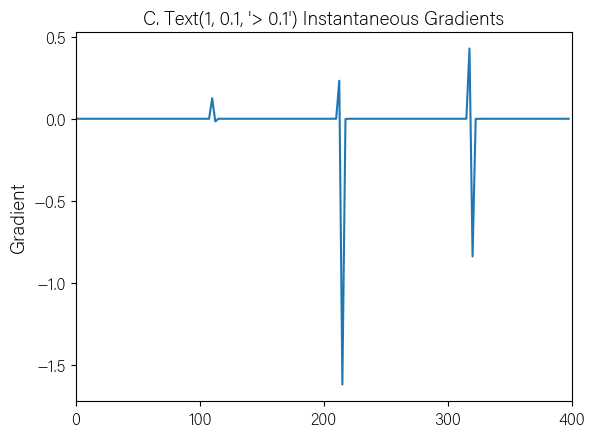

pr inc 40 401 0.1 25 ['0', '100', '200', '300', '400', '500', '600', '700', '800', '900', '1000']


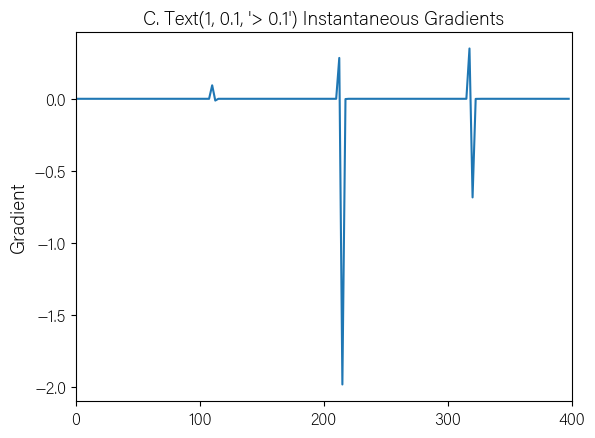

pr inc 40 401 0.1 25 ['0', '100', '200', '300', '400', '500', '600', '700', '800', '900', '1000']


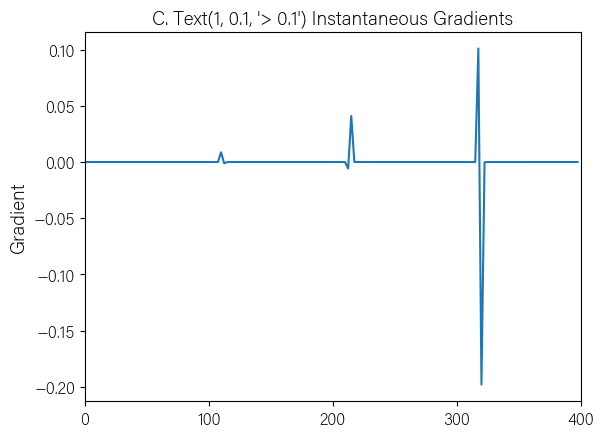

pr inc 40 401 0.1 25 ['0', '100', '200', '300', '400', '500', '600', '700', '800', '900', '1000']


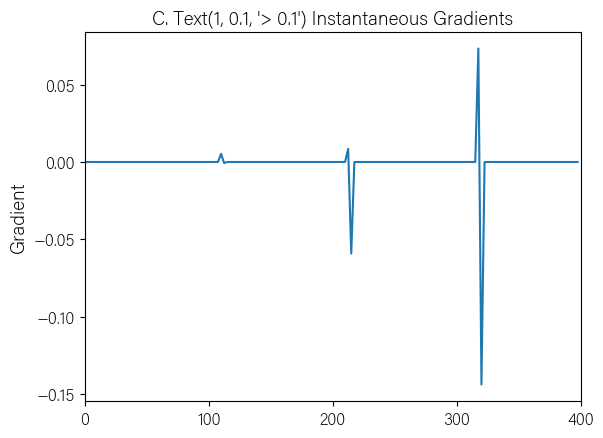

pr inc 40 401 0.1 25 ['0', '100', '200', '300', '400', '500', '600', '700', '800', '900', '1000']


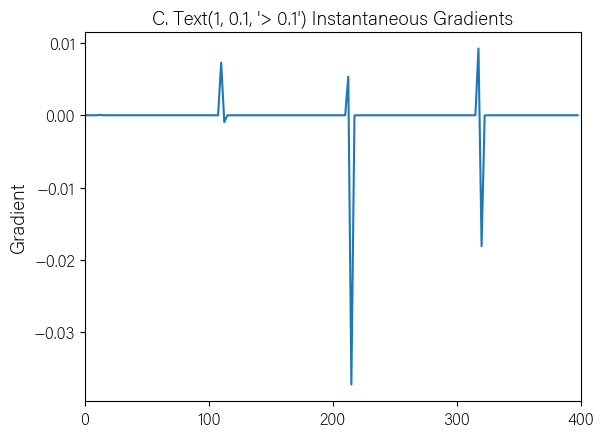

pr inc 40 401 0.1 25 ['0', '100', '200', '300', '400', '500', '600', '700', '800', '900', '1000']


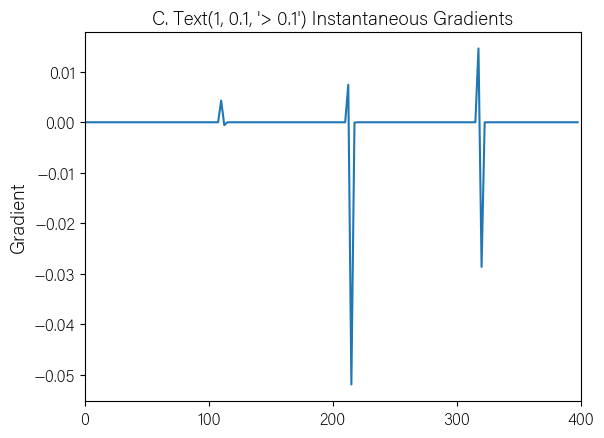

pr inc 40 401 0.1 25 ['0', '100', '200', '300', '400', '500', '600', '700', '800', '900', '1000']


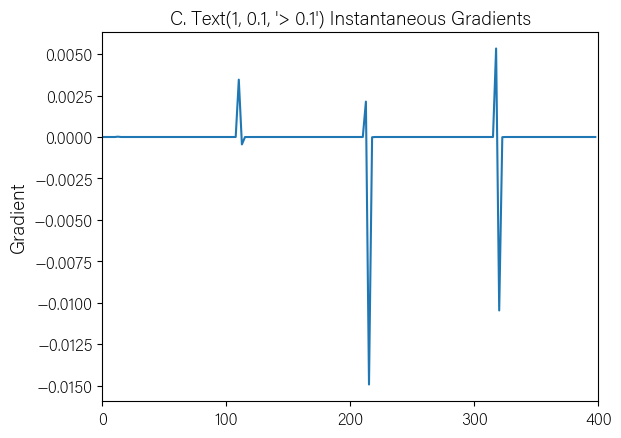

pr inc 40 401 0.1 25 ['0', '100', '200', '300', '400', '500', '600', '700', '800', '900', '1000']


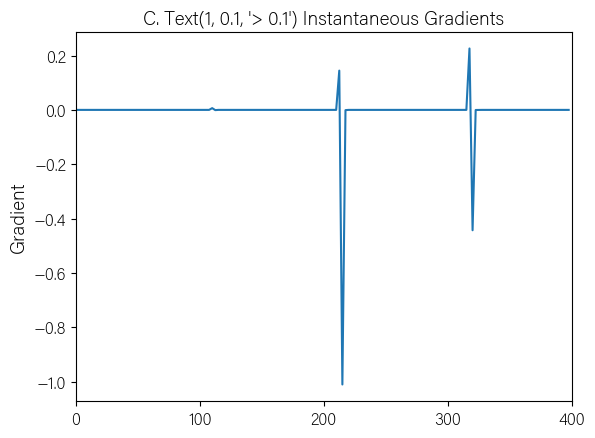

pr inc 40 401 0.1 25 ['0', '100', '200', '300', '400', '500', '600', '700', '800', '900', '1000']


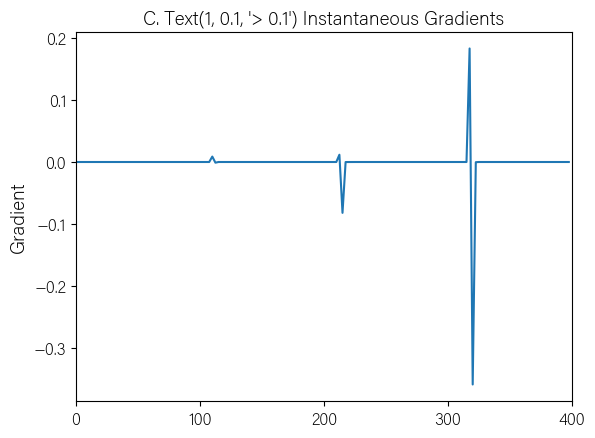

pr inc 40 401 0.1 25 ['0', '100', '200', '300', '400', '500', '600', '700', '800', '900', '1000']


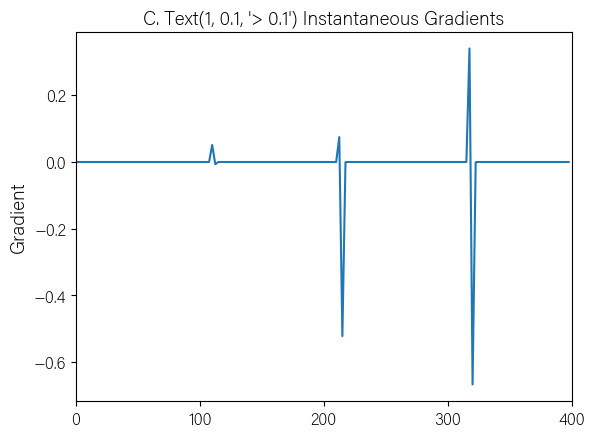

pr inc 40 401 0.1 25 ['0', '100', '200', '300', '400', '500', '600', '700', '800', '900', '1000']


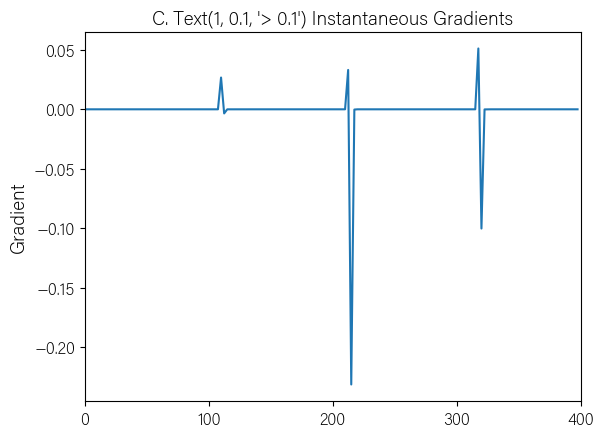

pr inc 40 401 0.1 25 ['0', '100', '200', '300', '400', '500', '600', '700', '800', '900', '1000']


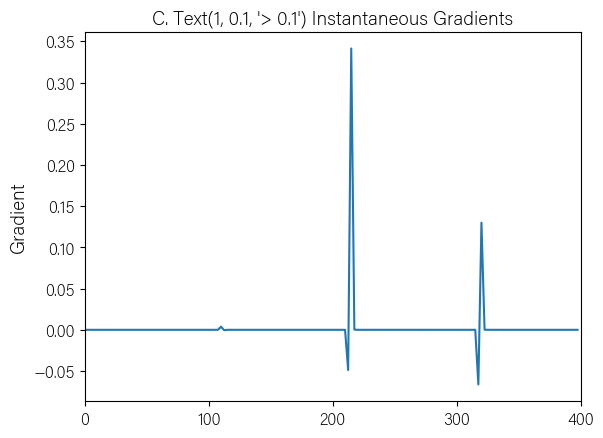

In [15]:
fig_4v2(sliding_grads, start = 0, end = 401, inc = 1000)

In [ ]:
def fig_4v3(sliding_grads, start = 0, end = 40, inc = 1000, window_size = 25, dt = 0.1):
    colors = ["red", "orange",  "green", "blue", "#F26858", "#1B9AAA" , "#A4B547",  "#201E50", "#d62728","#2CA02C" ]#plt.cm.tab10(np.linspace(0, 1, num_chunks))  # 10 distinct colors

    
    def set_ticks(windowed_axis = True, inc = inc, N = end, dt = dt):
        
       # print(" ..", windowed_size)
        scale = window_size if windowed_axis else 1
        inc = inc // scale
        if windowed_axis == True:
            print("pr", "inc", inc, N,dt, scale, [f'{i*dt*scale:.0f}' for i in range(0,N+1,inc)])
        plt.xticks(range(0,N+1,inc), [f'{i*dt*scale:.0f}' for i in range(0,N+1,inc)], fontproperties=prop)
 
    T2 = sliding_grads.get('T2_out').cpu().detach().numpy()
    fig = plt.figure(figsize = (10, 12))          
    plt.subplot(3, 2, 1)
    

    print(T2.shape)
    for i in range(10):
        if i !=1:
            
            plt.plot(T2[:,i], color="grey", linewidth=1.5, label=f'{i}')  # use individual color
        if i ==1 :
            plt.plot(T2[:,2], color="orange", linewidth=1.5, label="1")  # use individual color

    plt.plot(T2[:,2], color="orange", linewidth=1.5, label="1")  # use individual color
            
            
    plt.title('B. All Output Layer Traces', fontsize=34, fontproperties=prop2)
    plt.ylabel('Neuron index', fontsize = 13, fontproperties=prop)
    set_ticks(False, N = int(end/dt))
    hi_color = 'black'
    hi_width = 1.5
    plt.xlim(start*100, int(end/dt))
    plt.yticks( fontproperties=prop) 
    plt.legend(np.arange(0,10,1), fontsize = 8, prop=prop, loc='lower left')

    plt.subplot(3, 2, 2)
    plt.imshow(T2.transpose(), aspect='auto', cmap='gist_rainbow', vmin = 0.0, vmax = 1.0)
    #plt.colorbar()#fontproperties=prop)
    colorbar = plt.colorbar()
    
    for label in colorbar.ax.get_yticklabels():
        label.set_fontproperties(prop)  # Apply the custom font to each tick label

    
    plt.ylabel('Neuron output', fontsize = 13, fontproperties=prop)
    plt.title('B. Output Layer Raster Plot', fontsize=34, fontproperties=prop2)
    set_ticks(False, N = int(end/dt))
    plt.xlim(start*100, int(end/dt))c

    for l, label, numbers in zip([1,2], ['Hidden', 'Output'], [['D.', 'F.'], ['D.', 'F.']]):
        plot_idx = 5 if l == 1 else 3 
        plt.subplot(3, 2, plot_idx+1)
        if l == 1:
            changes = sliding_grads.get('sliding_grad_1')
            #print(len(changes))
        else:
            changes = sliding_grads.get('sliding_grad_2')
            #print(len(changes))
        vmin=-0.1; vmax=0.1
        plt.imshow(changes.detach().cpu().numpy().transpose(), aspect='auto', cmap='gnuplot', vmin=vmin, vmax=vmax)
        cbar = plt.colorbar(ticks=[vmin, 0.0, vmax])
       
        cbar.ax.set_yticklabels(['< -0.1', '0', '> 0.1'])
        
        set_ticks()
        
        plt.ylabel('Gradient (flattened)', fontsize = 13, fontproperties=prop)
        plt.title(f'{numbers[1]} {label} Gradients Raster Plot', fontproperties=prop2)
        plt.xlim(start//dt//window_size, end//dt//window_size)
        plt.yticks( fontproperties=prop) 
        
        
        plt.subplot(3, 2, plot_idx)
        if l == 1:
            changes = changes[:, ::10] # Too many values to plot.
        print("CHANGES", changes.shape)
        
        if l == 2 or l == 1:

            # Convert to numpy
            changes_np = changes.cpu().numpy()

            # Number of chunks
            num_chunks = changes_np.shape[1] // 10
                       
            for i in range(10):
                # Extract each chunk
                chunk = changes_np[:, i*num_chunks:(i+1)*num_chunks]

                if l==2 and i == 1:
                    plt.plot(chunk - i*1*(l-1) - i*200*(2-l), color = colors[i], linewidth=0.9)
                
               #     plt.ylim(-10,1)
               #     plt.yticks([])    
                if l==1 and i == 1:
                    plt.plot(chunk - i*1*(l-1) - i*200*(2-l), color = colors[i], linewidth=0.9)
               # 
               #     plt.ylim(-1900,200)
               #     plt.yticks([])    
                

                 
                 
        else:
            plt.plot(changes.cpu().numpy())

        set_ticks()
        plt.title(f'{numbers[0]} {label} Correct Neuron Instantaneous Gradients', fontproperties=prop2)
        plt.ylabel('Gradient (flattened)', fontsize = 14, fontproperties=prop)
       # plt.axvspan(210, 240, edgecolor=hi_color, linestyle='--', linewidth=hi_width, facecolor='none')
       # plt.axvspan(110, 150, edgecolor=hi_color, linestyle='--', linewidth=hi_width, facecolor='none')
        plt.xlim(start//dt//window_size, end//dt//window_size)
        plt.yticks( fontproperties=prop) 

        for label in cbar.ax.get_yticklabels():
            label.set_fontproperties(prop)  # Apply the custom font to each tick label
        

    fig.text(0.25, -0.01, 'Time (ms)', ha='center', fontsize=13, fontproperties=prop)
    fig.text(0.75, -0.01, 'Time (ms)', ha='center', fontsize=13, fontproperties=prop)
    plt.tight_layout()
    
    plt.show()
    


(4000, 10)
pr inc 40 401 0.1 25 ['0', '100', '200', '300', '400', '500', '600', '700', '800', '900', '1000']
CHANGES torch.Size([160, 7840])
pr inc 40 401 0.1 25 ['0', '100', '200', '300', '400', '500', '600', '700', '800', '900', '1000']
pr inc 40 401 0.1 25 ['0', '100', '200', '300', '400', '500', '600', '700', '800', '900', '1000']
CHANGES torch.Size([160, 1000])
pr inc 40 401 0.1 25 ['0', '100', '200', '300', '400', '500', '600', '700', '800', '900', '1000']


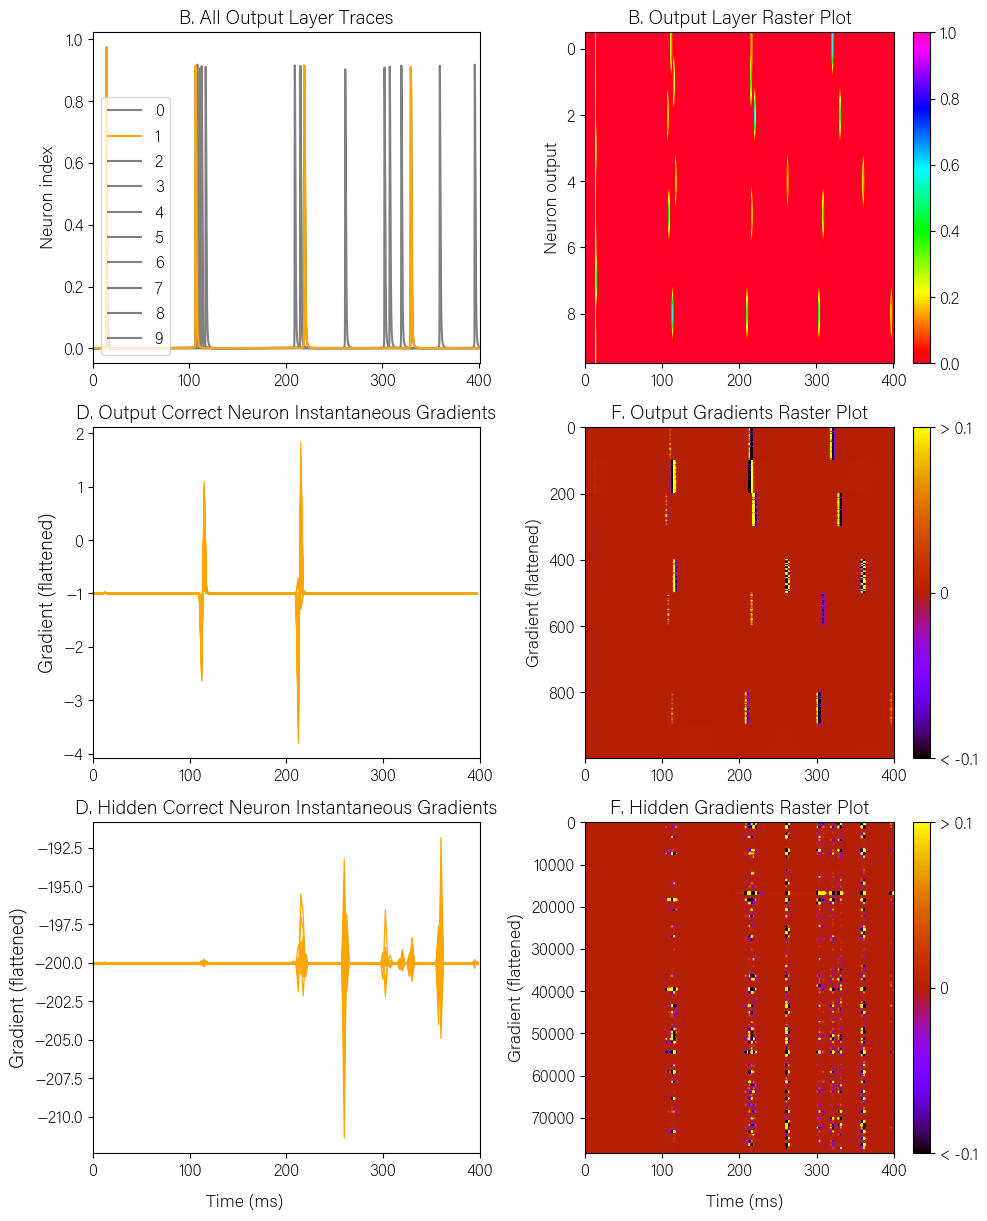

In [17]:
fig_4v3(sliding_grads, start = 0, end = 401, inc = 1000)

In [ ]:
def fig_4v4(sliding_grads, start=0, end=40, inc=1000, window_size=25, dt=0.1):
    colors = ["red", "orange", "green", "blue", "#F26858", "#1B9AAA", "#A4B547", "#201E50", "#d62728", "#2CA02C"]

    def set_ticks(ax, windowed_axis=True, inc=inc, N=end, dt=dt):
        scale = window_size if windowed_axis else 1
        inc_scaled = inc // scale
        ax.set_xticks(range(0, N + 1, inc_scaled))
        ax.set_xticklabels([f'{i * dt * scale:.0f}' for i in range(0, N + 1, inc_scaled)], fontproperties=prop)

    T2 = sliding_grads.get('T2_out').cpu().detach().numpy()

    fig = plt.figure(figsize=(10, 10))
    gs = gridspec.GridSpec(2, 2, height_ratios=[2, 3]) 

    # --- 1. Output Layer Traces ---
    ax1 = fig.add_subplot(gs[0, 1])
    for i in range(10):
        color = "orange" if i == 1 else "grey"
        if i == 1:
            ax1.plot(T2[:, i], color=color, linewidth=1.5, label=f'{i}')
        
        elif i == 9:
            ax1.plot(T2[:, i], color=color, linewidth=1.5, alpha = 0.25, label='Others')
        else:
            ax1.plot(T2[:, i], color=color, linewidth=1.5, alpha = 0.25)
    ax1.set_title(r"$\bf{C.}$ All Output Layer Traces", fontsize=34, fontproperties=prop2)
    ax1.set_ylabel('Neuron index', fontsize=13, fontproperties=prop)
    for label in ax1.get_yticklabels():
        label.set_fontproperties(prop)

    set_ticks(ax1, windowed_axis=False, N=int(end / dt))
    ax1.set_xlim(start * 100, int(end / dt))
    ax1.legend(["Others", "1"], fontsize=8, prop=prop, loc='lower left')

    ax2 = fig.add_subplot(gs[0, 0])
    for i in range(10):
        ax2.plot(T2[:, i], color=colors[i], linewidth=1.5, label=f'{i}')
    ax2.set_title(r"$\bf{B.}$ All Output Layer Traces", fontsize=34, fontproperties=prop2)
    ax2.set_ylabel('Neuron index', fontsize=13, fontproperties=prop)
    for label in ax2.get_yticklabels():
        label.set_fontproperties(prop)

    set_ticks(ax2, windowed_axis=False, N=int(end / dt))
    ax2.set_xlim(start * 100, int(end / dt))
    ax2.legend(np.arange(0, 10, 1), fontsize=8, prop=prop, loc='lower left')

    # --- 3–6. Gradient plots ---
    for l, label, numbers in zip([1, 2], ['Hidden', 'Output'], [['E.', 'E.'], ['D.', 'D.']]):
        changes_key = 'sliding_grad_1' if l == 1 else 'sliding_grad_2'
        changes = sliding_grads.get(changes_key)

        ax_line = fig.add_subplot(gs[1, -l+2])

        if l == 1:
            changes = changes[:, ::10]  # too many values otherwise
        print("CHANGES", changes.shape)

        changes_np = changes.cpu().numpy()
        num_chunks = changes_np.shape[1] // 10

        for i in range(10):
            chunk = changes_np[:, i * num_chunks:(i + 1) * num_chunks]
            offset_chunk = chunk - i * 1 * (l - 1) - i * 200 * (2 - l)
            if l == 2:
                ax_line.plot(chunk - i * 1 * (l - 1) - i * 200 * (2 - l), color=colors[i], linewidth=0.1)
                ax_line.set_ylim(-10, 1)
                ax_line.set_yticks([])
                

                if i == 1:
                    x = np.arange(offset_chunk.shape[0])
                    y_min = -1.5
                    y_max = -0.5

                    # Fill the background in that x/y range
                    ax_line.fill_between(x, y_min, y_max, color='lightgray', alpha=0.4)
            if l == 1:
                ax_line.plot(chunk - i * 1 * (l - 1) - i * 200 * (2 - l), color=colors[i], linewidth=0.05)
                ax_line.set_ylim(-2000, 200)
                ax_line.set_yticks([])
                
                if i == 1:
                    x = np.arange(offset_chunk.shape[0])
                    y_min = -300
                    y_max = -100

                    # Fill the background in that x/y range
                    ax_line.fill_between(x, y_min, y_max, color='lightgray', alpha=0.4)
                
                
        set_ticks(ax_line)#r"$\bf{A.}$ All Output Layer Traces"
        ax_line.set_title(rf'$\bf{{{numbers[0]}}}$ {label} Instantaneous Gradients', fontproperties=prop2)
        ax_line.set_ylabel('Gradient (flattened)', fontsize=14, fontproperties=prop)
        ax_line.set_xlim(start // dt // window_size, end // dt // window_size)

    # Shared x labels
    fig.text(0.25, -0.01, 'Time (ms)', ha='center', fontsize=13, fontproperties=prop)
    fig.text(0.75, -0.01, 'Time (ms)', ha='center', fontsize=13, fontproperties=prop)

    plt.tight_layout()
    plt.show()

CHANGES torch.Size([160, 7840])
CHANGES torch.Size([160, 1000])


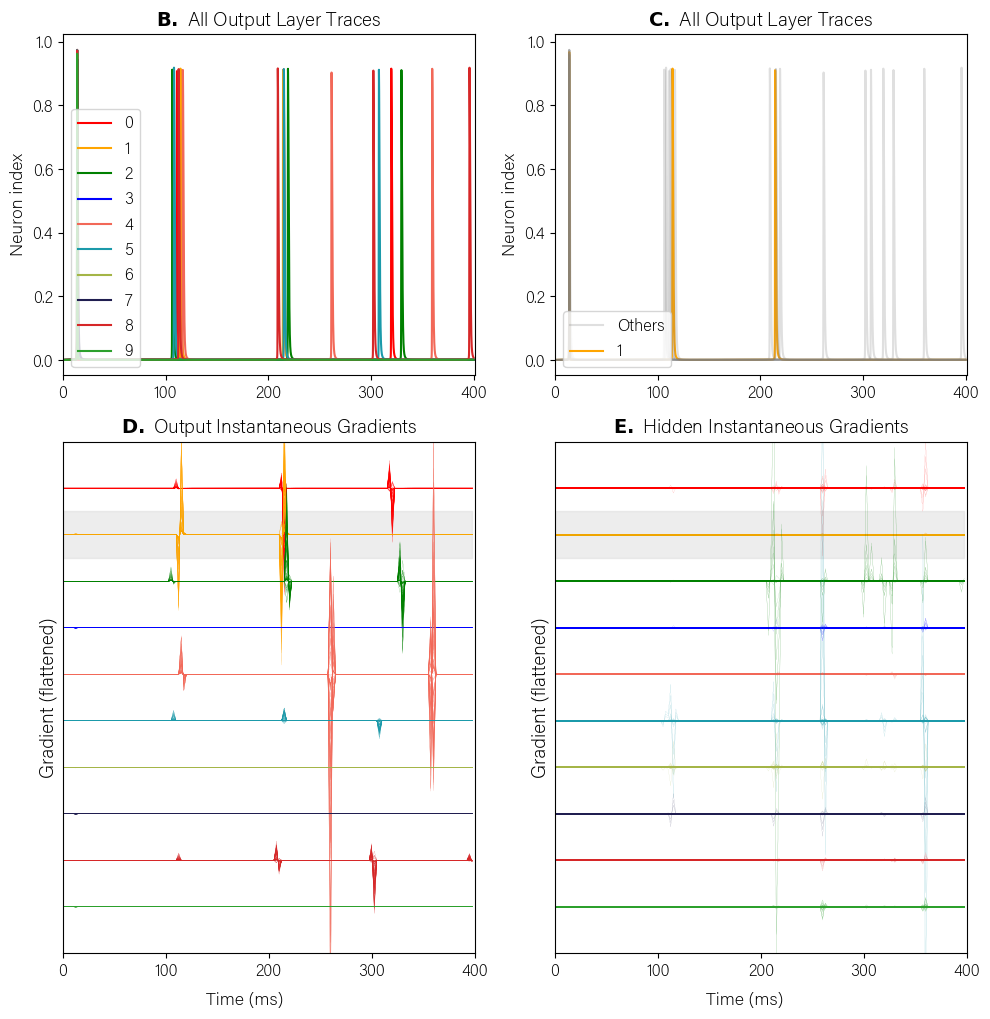

In [23]:
fig_4v4(sliding_grads, start = 0, end = 401, inc = 1000)

In [ ]:
def fig_4v5(sliding_grads, start = 0, end = 40, inc = 1000, window_size = 25, dt = 0.1):
    colors = ["red", "orange",  "green", "blue", "#F26858", "#1B9AAA" , "#A4B547",  "#201E50", "#d62728","#2CA02C" ]#plt.cm.tab10(np.linspace(0, 1, num_chunks))  # 10 distinct colors
    
    def set_ticks(windowed_axis = True, inc = inc, N = end, dt = dt):
        
       # print(" ..", windowed_size)
        scale = window_size if windowed_axis else 1
        inc = inc // scale
        if windowed_axis == True:
            print("pr", "inc", inc, N,dt, scale, [f'{i*dt*scale:.0f}' for i in range(0,N+1,inc)])
        plt.xticks(range(0,N+1,inc), [f'{i*dt*scale:.0f}' for i in range(0,N+1,inc)], fontproperties=prop)
 
    T2 = sliding_grads.get('T2_out').cpu().detach().numpy()
    fig = plt.figure(figsize = (5, 2))          
    

    for l, label, numbers in zip([1,2], ['Hidden', 'Output'], [['D.', 'F.'], ['D.', 'F.']]):
        plot_idx = 5 if l == 1 else 3 
        changes_key = 'sliding_grad_1' if l == 1 else 'sliding_grad_2'
        changes = sliding_grads.get(changes_key)

        
        if l == 2:
            # Convert to numpy
            changes_np = changes.cpu().numpy()

            # Number of chunks
            num_chunks = changes_np.shape[1] // 10
    
            for i in range(10):
                # Extract each chunk
                chunk = changes_np[:, i*num_chunks:(i+1)*num_chunks]

                if l==2 and i == 1:
                    plt.plot(chunk - i*1*(l-1) - i*200*(2-l), color = colors[i], linewidth=0.9)
                
               #     plt.ylim(-10,1)
               #     plt.yticks([])    
                if l==1 and i == 1:
                    plt.plot(chunk - i*1*(l-1) - i*200*(2-l), color = colors[i], linewidth=0.9)
               # 
               #     plt.ylim(-1900,200)
               #     plt.yticks([])    
                

        set_ticks()
        plt.ylabel('Gradient (flattened)', fontsize = 14, fontproperties=prop)
        plt.xlim(start//dt//window_size, end//dt//window_size)
        plt.yticks( fontproperties=prop) 

      
    fig.text(0.5, -0.01, 'Time (ms)', ha='center', fontsize=13, fontproperties=prop)
    plt.tight_layout()
    
    plt.show()
    BNNConfig().sim_t = 4000
   

pr inc 40 401 0.1 25 ['0', '100', '200', '300', '400', '500', '600', '700', '800', '900', '1000']
pr inc 40 401 0.1 25 ['0', '100', '200', '300', '400', '500', '600', '700', '800', '900', '1000']


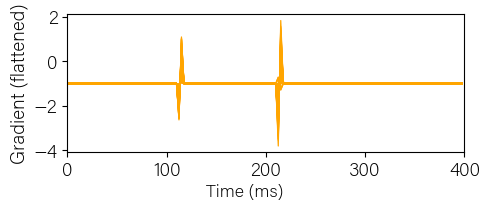

In [111]:
fig_4v5(sliding_grads, start = 0, end = 401, inc = 1000)